## Exploratory Data Analysis - Titanic Dataset
I am starting by importing libraries and using head() to initially inspect the dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


I am going to remove the following features as they are not relevant: Name, Ticket, Embarked

In [2]:
df.drop('Name',axis=1, inplace=True)
df.drop('Ticket',axis=1, inplace=True)
df.drop('Embarked',axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin
0,1,0,3,male,22.0,1,0,7.2500,NaN
1,2,1,1,female,38.0,1,0,71.2833,C85
2,3,1,3,female,26.0,0,0,7.9250,NaN
3,4,1,1,female,35.0,1,0,53.1000,C123
4,5,0,3,male,35.0,0,0,8.0500,NaN


I am now checking for missing values

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Cabin          687
dtype: int64

There are missing values for 'Age' and 'Cabin'.  I am unsure how to proceed.  Age could be a very significant factor in chance of survival, and so replacing absent data with an average may significantly distort findings.  Cabin could also be very significant.  I am choosing to display unique values for Cabin to investigate further.

In [4]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

I am also checking the shape of the dataset

In [5]:
df.shape

(891, 9)

Given that 687 of the 891 records do not have an entry for Cabin, and that I could only be guessing at what the data means (e.g. letter could refer to floor of the ship, but also may not), I am minded to currently ignore this column

I am creating a Barplot to show survival rates based on sex

Text(0, 0.5, 'Survival rate')

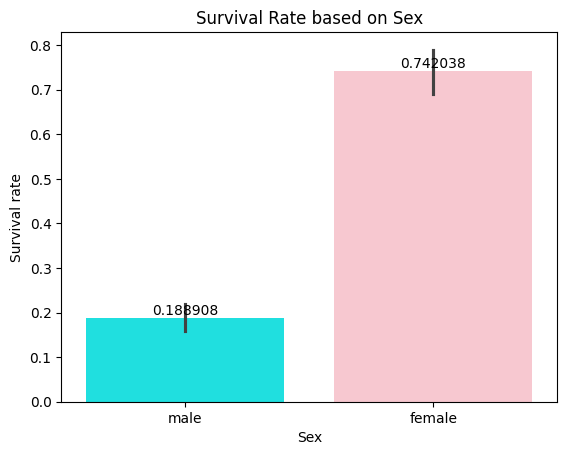

In [6]:
# Barplot
bp = sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', legend=False, palette=['cyan','pink'])
# Title added
bp.set_title('Survival Rate based on Sex')
# X-axis label changed to 'Sex'
bp.set_xlabel('Sex')
# Bar labels added to see actual figures
bp.bar_label(bp.containers[0])
bp.bar_label(bp.containers[1])
# Y-axis label changed to 'Survival rate'
bp.set_ylabel('Survival rate')

This chart shows the survival rate for women is 74%, compared to 19% for men

I am now creating a Barplot to show survival rates based on passenger class

Text(0, 0.5, 'Survival rate')

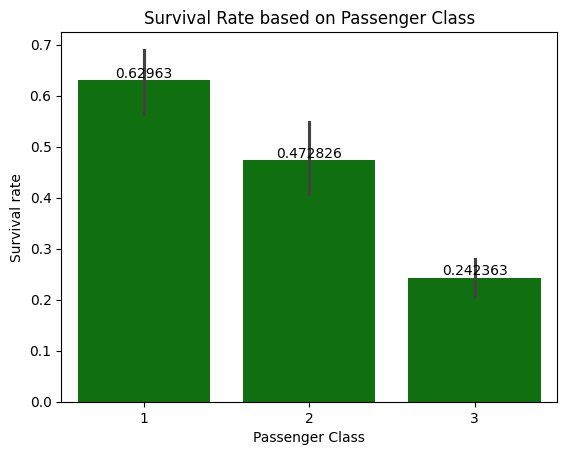

In [7]:
# Barplot
bp = sns.barplot(x='Pclass', y='Survived', data=df, color='green')
# Title added
bp.set_title('Survival Rate based on Passenger Class')
# X-axis label changed to 'Passenger Class'
bp.set_xlabel('Passenger Class')
# Bar labels added to see actual figures
bp.bar_label(bp.containers[0])
# Y-axis label changed to 'Survival rate'
bp.set_ylabel('Survival rate')

The chart shows that there is a correlation between passenger class and survival rate (the higher the passenger class, the higher the survival rate), with first class passengers having a survival rate of 63%

I don't know what the columns 'SibSp' and 'Parch' represent, but will create charts visualising survival rates for these, to see if either could potentially be a greater factor than sex or passenger class

Text(0, 0.5, 'Survival rate')

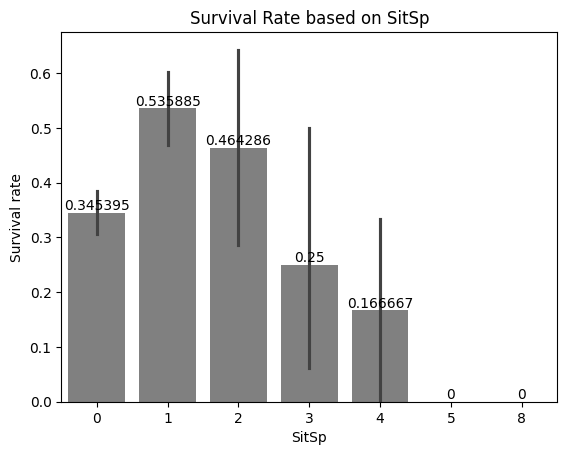

In [8]:
# Barplot
bp = sns.barplot(x='SibSp', y='Survived', data=df, color='gray')
# Title added
bp.set_title('Survival Rate based on SitSp')
# X-axis label changed to 'SitSp'
bp.set_xlabel('SitSp')
# Bar labels added to see actual figures
bp.bar_label(bp.containers[0])
# Y-axis label changed to 'Survival rate'
bp.set_ylabel('Survival rate')

There is significant variance in survival rate with this variable, but the highest survival rate (54%) is lower than the highest for sex or passenger class

In [9]:
print(df['SibSp'].value_counts())

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


I have returned the count of each unique value for SibSp, and found that the frequency is low for all values except 0 and 1.  But there does clearly seem to be a relation between this variable and survival rate - highest at 1, and then decrease beyond than.  I have now Googled the data set for description of the features.  SibSp is the number of sibling/spouses on board; Parch is the number of parents/children on board.  As a sibling is significantly different to a spouse and a parent is significatly different to a child, it is hard to make sense of this data.  However, I will present the Parch data.

Text(0, 0.5, 'Survival rate')

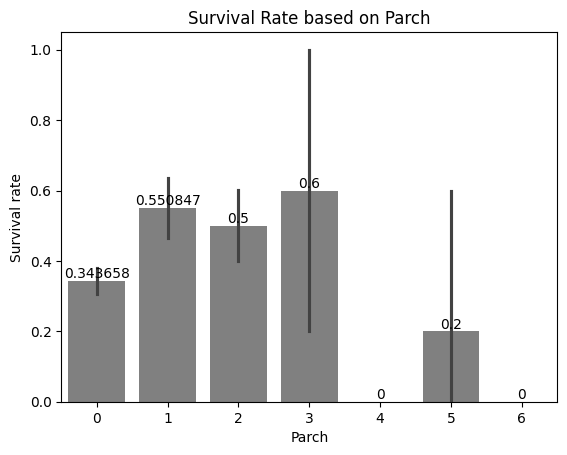

In [10]:
# Barplot
bp = sns.barplot(x='Parch', y='Survived', data=df, color='gray')
# Title added
bp.set_title('Survival Rate based on Parch')
# X-axis label changed to 'Parch'
bp.set_xlabel('Parch')
# Bar labels added to see actual figures
bp.bar_label(bp.containers[0])
# Y-axis label changed to 'Survival rate'
bp.set_ylabel('Survival rate')

I am now going to investigate the feature 'Fare'.  

Text(0.5, 1.0, 'Fares split by survival outcomee')

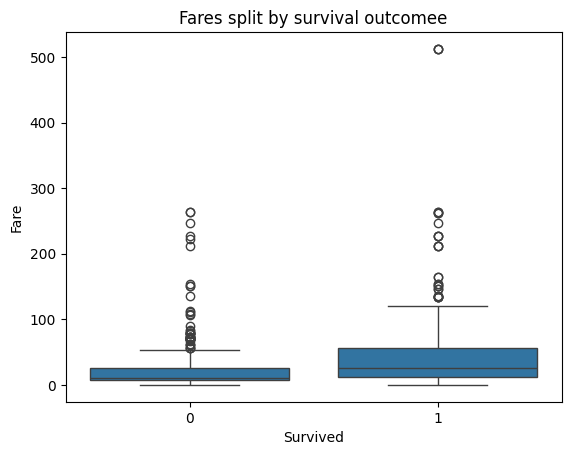

In [11]:
# Boxplot produced with title added
sns.boxplot(x='Survived', y='Fare', data=df).set_title('Fares split by survival outcomee')

This shows that the survival rate was higher amongst those who paid higher fares.  This is to be expected, as we have already seen a positive relationship between passenger class and survival rate, and higher class tickets will be more expensive.  It is possible that those paying the highest ticket prices had the highest standard of accommodation amongst first class passnegers, and there will be some relationship between Fare and social class.  It could be useful to interogate this data further - e.g. whether within each Passenger Class there is a relationship between Fare and survival.  

Text(0.5, 1.0, 'Fares split by survival outcome - First Class')

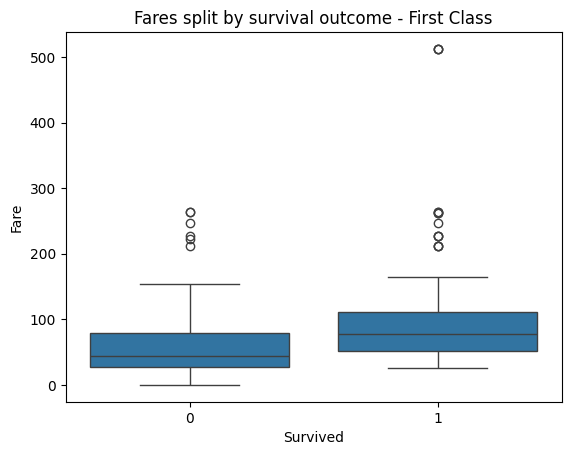

In [12]:
# First class passengers only selected
first_class = df.loc[df['Pclass']==1]
# Boxplot produced with title added
sns.boxplot(x='Survived', y='Fare', data=first_class).set_title('Fares split by survival outcome - First Class')

Text(0.5, 1.0, 'Fares split by survival outcome - Second Class')

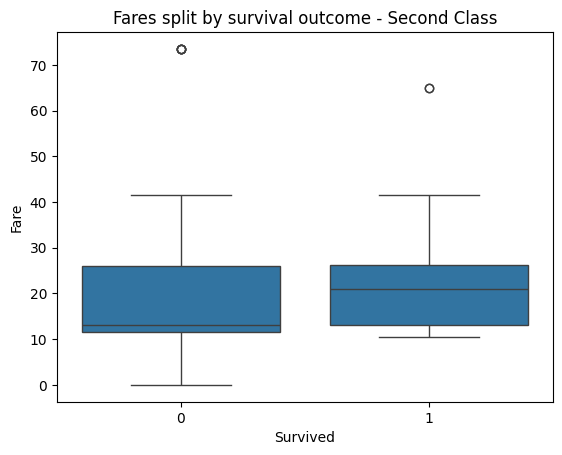

In [13]:
# Second class passengers only selected
second_class = df.loc[df['Pclass']==2]
# Boxplot produced with title added
sns.boxplot(x='Survived', y='Fare', data=second_class).set_title('Fares split by survival outcome - Second Class')

Text(0.5, 1.0, 'Fares split by survival outcome - Third Class')

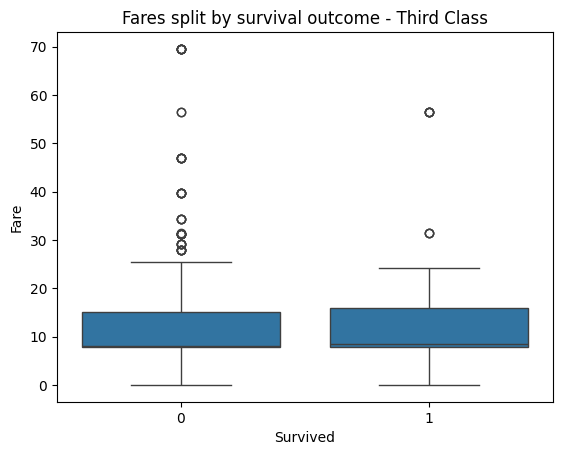

In [14]:
# Third class passengers only selected
third_class = df.loc[df['Pclass']==3]
# Boxplot produced with title added
sns.boxplot(x='Survived', y='Fare', data=third_class).set_title('Fares split by survival outcome - Third Class')

For each class, the mean fare is highest amongst those who survived.  The higher fare amongst survivers is most noticable in First, then Second class.

I finally am looking at the age category.  To investigate "women and children first" I am splitting children into different age categories.  The current legal definition of a child is under 18, but many people would see 16 year olds as young adults.  In context, "children first" may have referred to much younger children, as older children were of working age.

Text(0, 0.5, 'Survival rate')

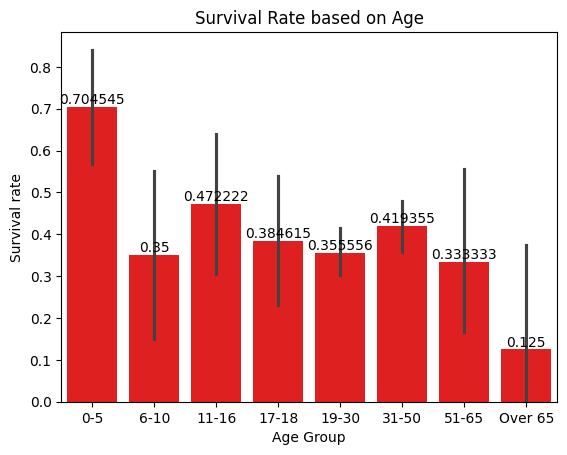

In [15]:
df['Age_group'] = pd.cut(df['Age'], [0,5,10,16,18,30,59,65,120], labels=['0-5','6-10','11-16','17-18','19-30','31-50','51-65','Over 65'])
# Barplot
bp = sns.barplot(x='Age_group', y='Survived', data=df, color='red')
# Title added
bp.set_title('Survival Rate based on Age')
# X-axis label changed to 'Age Group'
bp.set_xlabel('Age Group')
# Bar labels added to see actual figures
bp.bar_label(bp.containers[0])
# Y-axis label changed to 'Survival rate'
bp.set_ylabel('Survival rate')

I am now removing Cabin from the dataset so that using 'isna' will only show those with missing values for age.

In [17]:
df.drop('Cabin',axis=1, inplace=True)
df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_group
0,1,0,3,male,22.0,1,0,7.2500,19-30
1,2,1,1,female,38.0,1,0,71.2833,31-50
2,3,1,3,female,26.0,0,0,7.9250,19-30
3,4,1,1,female,35.0,1,0,53.1000,31-50
4,5,0,3,male,35.0,0,0,8.0500,31-50


In [22]:
no_age = df[df.isna().any(axis=1)]
no_age.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_group
5,6,0,3,male,NaN,0,0,8.4583,NaN
17,18,1,2,male,NaN,0,0,13.0000,NaN
19,20,1,3,female,NaN,0,0,7.2250,NaN
26,27,0,3,male,NaN,0,0,7.2250,NaN
28,29,1,3,female,NaN,0,0,7.8792,NaN


In [28]:
print("The mean survival of those with no age data is",no_age.Survived.mean())
print("The figure for the full dataset is",df.Survived.mean())

The mean survival of those with no age data is 0.2937853107344633
The figure for the full dataset is 0.3838383838383838


# Answers to the questions
### What is the most important factor in determining survival of the Titanic incident?
The most important factor I have found is sex.  The 74% survival rate of women is higher than any other grouping I have looked at.
### In the movie, the upper-class passengers were given preference on lifeboats. Does this show in the data?
Yes.  First class passengers have a significantly higher survival rate than second and third (63%, 47% & 24% respectively).  Furthermore, in each passenger class category there was a positive relationship between higher fare and survival.  "Upper-class" refers to social class, which is not a feature of the data set, but it is reasonable to assume that there is a positive correlation between passender class and social class, as well as fare and social class.
### “Women and children first”. Was this the case?
The data supports this for women (74% survival) and the youngest children (0-5, 70% survival rate).  However, whilst 11-16 year olds had a 47% survival rate (the 2nd highest group), 6-10 year olds only had a 35% survival rate (lower than each category from 19-50).  
### Add one other observation that you have noted in the dataset
The age is missing for 177 passengers.  This accounts for 20% of the dataset.  These passengers have a survival rate of 29% (significantly lower than the 38% of the full dataset).  If the ages are not missing at random, then it is possible the above information on age is misleading. 
